# 🌿 PLANesT-3D — PointNet++ Segmentation Robustness to Reconstruction Degradation
### Plant: `Ribes_04` — Classic PointNet++ baseline, trained once on GT, evaluated on GT + every noisy variant

This notebook is the **third stage** of the pipeline:

1. `PLANesT3D_Segmentation_Analysis.ipynb` → inspects/visualizes the clean GT annotation.
2. `PLANesT3D_Degradation_Pipeline.ipynb` → generates the controlled noisy variants
   (`noisy_reconstruction/degraded/<category>/<level>/`) + `manifest.csv`, **GT untouched**.
3. **This notebook** → trains a **classic PointNet++ (SSG) semantic segmentation** baseline on
   the clean GT point cloud, then evaluates the **same frozen model** (no retraining, no
   fine-tuning per variant) on GT and on **every** variant listed in `manifest.csv`, to measure
   how segmentation quality degrades as reconstruction quality drops.

**What this notebook saves — metrics & figures only, no `.ply` files:**

- `robustness_eval/tables/gt_baseline_metrics.json` — full GT baseline metrics
- `robustness_eval/tables/variant_metrics.csv` / `.json` — per-variant metrics (mIoU, per-class
  IoU/precision/recall/F1/support, overall accuracy, mean prediction confidence, inference time)
- `robustness_eval/tables/summary_degradation_table.csv` — the **Model / GT mIoU / Noisy mIoU /
  ΔmIoU / Degradation %** table, one row per `(category, level)`, ready to paste into slides
- `robustness_eval/tables/confusion_matrices/*.npy` — raw confusion matrix per variant + GT
- `robustness_eval/figures/*.png` — training curves, GT confusion matrix & per-class IoU,
  per-category mIoU-vs-severity charts, a degradation-% heatmap, per-class IoU degradation
  curves, and a confusion-matrix grid — all sized/styled for a presentation
- `robustness_eval/report/degradation_robustness_report.md` — auto-written summary you can copy
  straight into the paper/slides
- `robustness_eval/checkpoints/pointnet2_best.pth` — trained model weights (best val mIoU)

**Important scope note:** there is only **one** annotated GT point cloud for this plant, so the
train/val split used to monitor training convergence is a random **point-level** split of the
*same* cloud (not a held-out plant) — it only tells you the model has learned something, it is
**not** a generalization test. The actual robustness measurement — the thing this notebook is
built for — is running the **same frozen model** on the independently generated noisy variants
and comparing against the GT baseline.

> Runtime: **GPU strongly recommended** (Colab: `Runtime → Change runtime type → T4 GPU`).
> Training on CPU will work but will be slow.


## 1. Setup — install dependencies

In [ ]:
!pip install -q open3d plyfile scikit-learn pandas numpy matplotlib seaborn tqdm
print("Dependencies ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.3 MB/s eta 0:00:00
Dependencies ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration — paths (GT, noisy manifest, outputs)

In [ ]:
import os

# --- Dataset location -------------------------------------------------------
BASE_DIR   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
PLANT_NAME = "Ribes_04"

# GT reconstruction folder (read-only — same convention as the other notebooks)
GT_DIR = os.path.join(BASE_DIR, "gt_reconstruction")

PLY_PATH        = os.path.join(GT_DIR, f"{PLANT_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{PLANT_NAME}_Confidence.txt")

# Noisy / degraded reconstructions + manifest, produced by the Degradation Pipeline notebook
NOISY_DIR      = os.path.join(BASE_DIR, "noisy_reconstruction")
DEGRADED_DIR   = os.path.join(NOISY_DIR, "degraded")
MANIFEST_PATH  = os.path.join(DEGRADED_DIR, "manifest.csv")

# --- Output location (auto-created) — metrics & figures ONLY, never .ply ----
OUTPUT_DIR   = os.path.join(BASE_DIR, "outputs", PLANT_NAME)
ROBUST_DIR   = os.path.join(OUTPUT_DIR, "robustness_eval")
FIG_DIR      = os.path.join(ROBUST_DIR, "figures")
METRICS_DIR  = os.path.join(ROBUST_DIR, "tables")
CM_DIR       = os.path.join(METRICS_DIR, "confusion_matrices")
REPORT_DIR   = os.path.join(ROBUST_DIR, "report")
CKPT_DIR     = os.path.join(ROBUST_DIR, "checkpoints")

for d in [FIG_DIR, METRICS_DIR, CM_DIR, REPORT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Semantic class legend --------------------------------------------------
SEMANTIC_CLASS_NAMES = {
    0: "Background / Pot / Soil",
    1: "Stem",
    2: "Leaf",
}
NUM_CLASSES = len(SEMANTIC_CLASS_NAMES)

RANDOM_SEED = 42

print("GT folder      :", GT_DIR)
print("Manifest       :", MANIFEST_PATH)
print("Robustness out :", ROBUST_DIR)
print("  figures   ->", FIG_DIR)
print("  tables    ->", METRICS_DIR)
print("  report    ->", REPORT_DIR)
print("  checkpts  ->", CKPT_DIR)

GT folder      : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction
Manifest       : /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/manifest.csv
Robustness out : /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval
  figures   -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval/figures
  tables    -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval/tables
  report    -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval/report
  checkpts  -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval/checkpoints


## 3. Hyperparameters

Everything the model / training / evaluation depends on lives here, so the whole run is
reproducible and easy to tune from one place.

In [ ]:
import numpy as np

# --- Model input ------------------------------------------------------------
N_POINTS_PER_SAMPLE = 4096   # points per training crop AND per eval chunk (must be >= 1024)
USE_RGB_FEATURES    = True   # use RGB as extra per-point features if the GT .ply has color
ADDITIONAL_CHANNELS = 3 if USE_RGB_FEATURES else 0

# --- Training ----------------------------------------------------------------
EPOCHS                    = 40
BATCH_SIZE                = 8
LEARNING_RATE              = 1e-3
LR_DECAY_STEP              = 15
LR_DECAY_GAMMA              = 0.5
WEIGHT_DECAY                = 1e-4
N_TRAIN_SAMPLES_PER_EPOCH  = 300   # random crops drawn from the GT "train" point pool per epoch
N_VAL_SAMPLES_PER_EPOCH    = 60    # random crops drawn from the GT "val" point pool per epoch
TRAIN_POINT_FRACTION        = 0.85  # point-level split of the single GT cloud (see note above)

# --- Whole-cloud evaluation (GT + every noisy variant) ----------------------
N_REPEATS_EVAL = 4    # number of full-coverage passes averaged together per cloud

# --- Misc ---------------------------------------------------------------------
np.random.seed(RANDOM_SEED)
print(f"N_POINTS_PER_SAMPLE = {N_POINTS_PER_SAMPLE}, ADDITIONAL_CHANNELS = {ADDITIONAL_CHANNELS}")
print(f"EPOCHS = {EPOCHS}, BATCH_SIZE = {BATCH_SIZE}, N_REPEATS_EVAL = {N_REPEATS_EVAL}")

N_POINTS_PER_SAMPLE = 4096, ADDITIONAL_CHANNELS = 3
EPOCHS = 40, BATCH_SIZE = 8, N_REPEATS_EVAL = 4


## 4. Device

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu":
    print("⚠️  No GPU detected — training will be slow. In Colab: Runtime > Change runtime type > GPU.")
else:
    print("Using GPU:", torch.cuda.get_device_name(0))

Using GPU: Tesla T4


## 5. Load the clean GT point cloud (read-only, never modified)

In [ ]:
import open3d as o3d

def load_point_cloud(path):
    pcd = o3d.io.read_point_cloud(path)
    pts = np.asarray(pcd.points, dtype=np.float64)
    cols = np.asarray(pcd.colors, dtype=np.float64) if pcd.has_colors() else None
    return pts, cols

def load_label_file(path, dtype=np.int64):
    return np.loadtxt(path, dtype=dtype).reshape(-1)

gt_points, gt_rgb = load_point_cloud(PLY_PATH)
gt_semantic   = load_label_file(SEMANTIC_PATH, dtype=np.int64)
gt_instance   = load_label_file(INSTANCE_PATH, dtype=np.int64)
gt_confidence = load_label_file(CONFIDENCE_PATH, dtype=np.float64)

N_GT = gt_points.shape[0]
assert N_GT == gt_semantic.shape[0] == gt_instance.shape[0] == gt_confidence.shape[0], \
    "GT point / label counts do not match — check the gt_reconstruction files."

if gt_rgb is None:
    print("GT .ply has no RGB — falling back to zero features regardless of USE_RGB_FEATURES.")
    USE_RGB_FEATURES = False
    ADDITIONAL_CHANNELS = 0

# --- Fixed normalization frame, reused for GT AND every noisy variant -------
# (degradations don't recenter the cloud, so this keeps everything in the same coordinate frame)
GLOBAL_CENTER = gt_points.mean(axis=0)
bbox_min, bbox_max = gt_points.min(axis=0), gt_points.max(axis=0)
CHAR_SIZE = float(np.linalg.norm(bbox_max - bbox_min))   # bbox diagonal, same convention as the degradation notebook

def normalize_xyz(points):
    return (points - GLOBAL_CENTER) / CHAR_SIZE

def make_features(rgb):
    if not USE_RGB_FEATURES:
        return None
    return rgb.astype(np.float64) if rgb is not None else np.zeros((0, 3))

unique_semantic, semantic_counts = np.unique(gt_semantic, return_counts=True)

print(f"GT points          : {N_GT:,}")
print(f"Has RGB             : {gt_rgb is not None}  (USE_RGB_FEATURES={USE_RGB_FEATURES})")
print(f"Characteristic size : {CHAR_SIZE:.4f} (bbox diagonal, same units as the .ply)")
print("Class distribution:")
for u, c in zip(unique_semantic, semantic_counts):
    name = SEMANTIC_CLASS_NAMES.get(int(u), f"Unknown ({u})")
    print(f"  {u:>2} | {name:<28} | {c:>10,} pts | {100*c/N_GT:5.2f}%")

GT points          : 1,190,366
Has RGB             : True  (USE_RGB_FEATURES=True)
Characteristic size : 46.5006 (bbox diagonal, same units as the .ply)
Class distribution:
   1 | Stem                         |    174,696 pts | 14.68%
   2 | Leaf                         |  1,015,670 pts | 85.32%


## 6. Classic PointNet++ (SSG) — semantic segmentation architecture

Standard single-scale-grouping PointNet++ segmentation network (4 Set Abstraction levels +
4 Feature Propagation levels), the same architecture commonly used as the "classic baseline"
for point-cloud part/semantic segmentation. Implemented in pure PyTorch (no custom CUDA ops),
so it runs unmodified on any Colab GPU/CPU runtime.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


def square_distance(src, dst):
    return torch.sum((src[:, :, None, :] - dst[:, None, :, :]) ** 2, dim=-1)


def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long, device=device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]


def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.ones(B, N, device=device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    batch_indices = torch.arange(B, dtype=torch.long, device=device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids


def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long, device=device).view(1, 1, N).repeat(B, S, 1)
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat(1, 1, nsample)
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx


def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    fps_idx = farthest_point_sample(xyz, npoint)
    new_xyz = index_points(xyz, fps_idx)
    idx = query_ball_point(radius, nsample, xyz, new_xyz)
    grouped_xyz = index_points(xyz, idx)
    grouped_xyz_norm = grouped_xyz - new_xyz.view(B, npoint, 1, C)
    if points is not None:
        grouped_points = index_points(points, idx)
        new_points = torch.cat([grouped_xyz_norm, grouped_points], dim=-1)
    else:
        new_points = grouped_xyz_norm
    return new_xyz, new_points


def sample_and_group_all(xyz, points):
    device = xyz.device
    B, N, C = xyz.shape
    new_xyz = torch.zeros(B, 1, C, device=device)
    grouped_xyz = xyz.view(B, 1, N, C)
    if points is not None:
        new_points = torch.cat([grouped_xyz, points.view(B, 1, N, -1)], dim=-1)
    else:
        new_points = grouped_xyz
    return new_xyz, new_points


class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp, group_all):
        super().__init__()
        self.npoint, self.radius, self.nsample, self.group_all = npoint, radius, nsample, group_all
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel

    def forward(self, xyz, points):
        xyz = xyz.permute(0, 2, 1)
        if points is not None:
            points = points.permute(0, 2, 1)
        if self.group_all:
            new_xyz, new_points = sample_and_group_all(xyz, points)
        else:
            new_xyz, new_points = sample_and_group(self.npoint, self.radius, self.nsample, xyz, points)
        new_points = new_points.permute(0, 3, 2, 1)  # [B, C+D, nsample, npoint]
        for conv, bn in zip(self.mlp_convs, self.mlp_bns):
            new_points = F.relu(bn(conv(new_points)))
        new_points = torch.max(new_points, 2)[0]
        new_xyz = new_xyz.permute(0, 2, 1)
        return new_xyz, new_points


class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        xyz1 = xyz1.permute(0, 2, 1)
        xyz2 = xyz2.permute(0, 2, 1)
        points2 = points2.permute(0, 2, 1)
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape

        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm
            interpolated_points = torch.sum(index_points(points2, idx) * weight.view(B, N, 3, 1), dim=2)

        if points1 is not None:
            points1 = points1.permute(0, 2, 1)
            new_points = torch.cat([points1, interpolated_points], dim=-1)
        else:
            new_points = interpolated_points

        new_points = new_points.permute(0, 2, 1)
        for conv, bn in zip(self.mlp_convs, self.mlp_bns):
            new_points = F.relu(bn(conv(new_points)))
        return new_points


class PointNet2SemSegSSG(nn.Module):
    '''Classic PointNet++ (single-scale grouping) semantic segmentation baseline.'''

    def __init__(self, num_classes, additional_channel=3):
        super().__init__()
        self.additional_channel = additional_channel
        self.sa1 = PointNetSetAbstraction(1024, 0.1, 32, 3 + additional_channel, [32, 32, 64], False)
        self.sa2 = PointNetSetAbstraction(256, 0.2, 32, 64 + 3, [64, 64, 128], False)
        self.sa3 = PointNetSetAbstraction(64, 0.4, 32, 128 + 3, [128, 128, 256], False)
        self.sa4 = PointNetSetAbstraction(16, 0.8, 32, 256 + 3, [256, 256, 512], False)
        self.fp4 = PointNetFeaturePropagation(768, [256, 256])
        self.fp3 = PointNetFeaturePropagation(384, [256, 256])
        self.fp2 = PointNetFeaturePropagation(320, [256, 128])
        self.fp1 = PointNetFeaturePropagation(128 + 3 + additional_channel, [128, 128, 128])
        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyz, features):
        '''xyz: [B,3,N] normalized coordinates. features: [B,additional_channel,N] or None.'''
        l0_xyz, l0_points = xyz, features

        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)

        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        cat0 = torch.cat([l0_xyz, l0_points], 1) if l0_points is not None else l0_xyz
        l0_points = self.fp1(l0_xyz, l1_xyz, cat0, l1_points)

        x = self.drop1(F.relu(self.bn1(self.conv1(l0_points))))
        x = self.conv2(x)
        x = F.log_softmax(x, dim=1)
        return x.permute(0, 2, 1)  # [B, N, num_classes] log-probabilities


print("PointNet++ (SSG) segmentation model defined.")

PointNet++ (SSG) segmentation model defined.


## 7. Training data — random point crops from the GT cloud

Only one GT cloud exists, so "train" and "val" are a random **point-level** split of it (85/15
by default). Each `__getitem__` draws a fresh random crop of `N_POINTS_PER_SAMPLE` points from
its pool, with light augmentation (random Z-rotation, jitter, scale) — this is purely to get a
convergence signal during training, **not** a generalization benchmark.

In [ ]:
from torch.utils.data import Dataset, DataLoader

rng_split = np.random.default_rng(RANDOM_SEED)
perm = rng_split.permutation(N_GT)
n_train = int(round(N_GT * TRAIN_POINT_FRACTION))
train_pool = perm[:n_train]
val_pool   = perm[n_train:]

gt_features_full = make_features(gt_rgb)  # None or [N,3] RGB in [0,1]
gt_xyz_norm_full  = normalize_xyz(gt_points)


class PlantPatchDataset(Dataset):
    def __init__(self, points_norm, features, labels, index_pool, n_points, samples_per_epoch,
                 augment=True, seed=0):
        self.points_norm = points_norm
        self.features = features
        self.labels = labels
        self.index_pool = index_pool
        self.n_points = n_points
        self.samples_per_epoch = samples_per_epoch
        self.augment = augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, _):
        replace = len(self.index_pool) < self.n_points
        sel = self.rng.choice(self.index_pool, size=self.n_points, replace=replace)
        pts = self.points_norm[sel].copy()
        lbl = self.labels[sel].copy()
        feat = self.features[sel].copy() if self.features is not None else np.zeros((self.n_points, 0))

        if self.augment:
            theta = self.rng.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float64)
            pts = pts @ R.T
            pts = pts + self.rng.normal(0, 0.005, size=pts.shape)
            pts = pts * self.rng.uniform(0.9, 1.1)

        pts_t = torch.from_numpy(pts.astype(np.float32)).transpose(0, 1)     # [3, n_points]
        feat_t = torch.from_numpy(feat.astype(np.float32)).transpose(0, 1)   # [C, n_points]
        lbl_t = torch.from_numpy(lbl.astype(np.int64))
        return pts_t, feat_t, lbl_t


train_ds = PlantPatchDataset(gt_xyz_norm_full, gt_features_full, gt_semantic, train_pool,
                              N_POINTS_PER_SAMPLE, N_TRAIN_SAMPLES_PER_EPOCH, augment=True, seed=RANDOM_SEED)
val_ds   = PlantPatchDataset(gt_xyz_norm_full, gt_features_full, gt_semantic, val_pool,
                              N_POINTS_PER_SAMPLE, N_VAL_SAMPLES_PER_EPOCH, augment=False, seed=RANDOM_SEED + 1)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train point pool: {len(train_pool):,} | Val point pool: {len(val_pool):,}")
print(f"Train crops/epoch: {len(train_ds)} | Val crops/epoch: {len(val_ds)}")

Train point pool: 1,011,811 | Val point pool: 178,555
Train crops/epoch: 300 | Val crops/epoch: 60


## 8. Class-imbalance weighting + model / optimizer setup

In [ ]:
class_freq = semantic_counts / semantic_counts.sum()
class_weights = 1.0 / np.sqrt(np.clip(class_freq, 1e-6, None))
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights (inverse sqrt-frequency):", dict(zip(unique_semantic.tolist(), np.round(class_weights, 3).tolist())))

model = PointNet2SemSegSSG(NUM_CLASSES, additional_channel=ADDITIONAL_CHANNELS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA)
criterion = nn.NLLLoss(weight=class_weights_t)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Class weights (inverse sqrt-frequency): {1: 2.121, 2: 0.879}
Model parameters: 967,555


## 9. Metric utilities (confusion matrix → per-class IoU / precision / recall / F1 / mIoU)

Used both for quick per-epoch val monitoring and for the final GT / noisy-variant evaluation.

In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import precision_recall_fscore_support


def compute_metrics(y_true, y_pred, num_classes=NUM_CLASSES):
    labels = list(range(num_classes))
    cm = sk_confusion_matrix(y_true, y_pred, labels=labels)
    iou_per_class = np.full(num_classes, np.nan)
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = tp + fp + fn
        if denom > 0:
            iou_per_class[c] = tp / denom
    miou = float(np.nanmean(iou_per_class))
    overall_acc = float(np.trace(cm) / max(cm.sum(), 1))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    return {
        "confusion_matrix": cm,
        "iou_per_class": iou_per_class,
        "miou": miou,
        "overall_accuracy": overall_acc,
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "support_per_class": support,
    }


def quick_val_miou(model, loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for pts, feat, lbl in loader:
            pts, feat = pts.to(DEVICE), feat.to(DEVICE)
            feat_arg = feat if feat.shape[1] > 0 else None
            logits = model(pts, feat_arg)
            pred = logits.argmax(dim=-1).cpu().numpy().reshape(-1)
            all_pred.append(pred)
            all_true.append(lbl.numpy().reshape(-1))
    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    return compute_metrics(all_true, all_pred)["miou"]

print("Metric utilities ready.")

Metric utilities ready.


## 10. Train the baseline

In [ ]:
# --- Build a full-length (NUM_CLASSES) count vector, indexed by class id -----
# (np.unique only returns classes that are actually present, which can be < NUM_CLASSES
#  if e.g. "Stem" has zero points in this plant — that mismatch caused the crash)
full_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
for u, c in zip(unique_semantic, semantic_counts):
    full_counts[int(u)] = c

missing_classes = [c for c in range(NUM_CLASSES) if full_counts[c] == 0]
if missing_classes:
    names = [SEMANTIC_CLASS_NAMES.get(c, str(c)) for c in missing_classes]
    print(f"⚠️  Classes with 0 points in this GT cloud: {names} — their weight is set high but "
          f"they'll never receive gradient (no samples), and eval metrics will just show NaN/0 IoU for them.")

class_freq = full_counts / full_counts.sum()
class_weights = 1.0 / np.sqrt(np.clip(class_freq, 1e-6, None))
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights (inverse sqrt-frequency):", dict(zip(range(NUM_CLASSES), np.round(class_weights, 3).tolist())))

model = PointNet2SemSegSSG(NUM_CLASSES, additional_channel=ADDITIONAL_CHANNELS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA)
criterion = nn.NLLLoss(weight=class_weights_t)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

⚠️  Classes with 0 points in this GT cloud: ['Background / Pot / Soil'] — their weight is set high but they'll never receive gradient (no samples), and eval metrics will just show NaN/0 IoU for them.
Class weights (inverse sqrt-frequency): {0: 2.989, 1: 0.008, 2: 0.003}
Model parameters: 967,555


In [ ]:
import time

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": []}
best_val_miou = -1.0
best_ckpt_path = os.path.join(CKPT_DIR, "pointnet2_best.pth")

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for pts, feat, lbl in train_loader:
        pts, feat, lbl = pts.to(DEVICE), feat.to(DEVICE), lbl.to(DEVICE)
        feat_arg = feat if feat.shape[1] > 0 else None
        optimizer.zero_grad()
        logits = model(pts, feat_arg)                      # [B, N, C] log-probs
        loss = criterion(logits.reshape(-1, NUM_CLASSES), lbl.reshape(-1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * pts.shape[0]
    train_loss = running_loss / len(train_ds)
    scheduler.step()

    model.eval()
    val_running_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for pts, feat, lbl in val_loader:
            pts, feat, lbl_gpu = pts.to(DEVICE), feat.to(DEVICE), lbl.to(DEVICE)
            feat_arg = feat if feat.shape[1] > 0 else None
            logits = model(pts, feat_arg)
            loss = criterion(logits.reshape(-1, NUM_CLASSES), lbl_gpu.reshape(-1))
            val_running_loss += loss.item() * pts.shape[0]
            all_pred.append(logits.argmax(dim=-1).cpu().numpy().reshape(-1))
            all_true.append(lbl.numpy().reshape(-1))
    val_loss = val_running_loss / len(val_ds)
    val_miou = compute_metrics(np.concatenate(all_true), np.concatenate(all_pred))["miou"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({"model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_miou": val_miou,
                    "additional_channel": ADDITIONAL_CHANNELS,
                    "num_classes": NUM_CLASSES}, best_ckpt_path)

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        elapsed = time.time() - t0
        print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_mIoU={val_miou:.4f} | "
              f"best_val_mIoU={best_val_miou:.4f} | {elapsed:6.1f}s elapsed")

print(f"\nTraining done. Best val mIoU = {best_val_miou:.4f} -> {best_ckpt_path}")

# reload the best checkpoint before any evaluation
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val mIoU {ckpt['val_miou']:.4f}) for evaluation.")

Epoch   1/40 | train_loss=0.5813 | val_loss=1.7116 | val_mIoU=0.4263 | best_val_mIoU=0.4263 |   24.9s elapsed
Epoch   5/40 | train_loss=0.1837 | val_loss=0.2193 | val_mIoU=0.7619 | best_val_mIoU=0.7709 |  124.0s elapsed
Epoch  10/40 | train_loss=0.1075 | val_loss=0.1047 | val_mIoU=0.8807 | best_val_mIoU=0.8807 |  251.8s elapsed
Epoch  15/40 | train_loss=0.0824 | val_loss=0.0756 | val_mIoU=0.9144 | best_val_mIoU=0.9144 |  381.2s elapsed
Epoch  20/40 | train_loss=0.0697 | val_loss=0.0616 | val_mIoU=0.9183 | best_val_mIoU=0.9225 |  513.3s elapsed
Epoch  25/40 | train_loss=0.0651 | val_loss=0.0550 | val_mIoU=0.9344 | best_val_mIoU=0.9344 |  643.5s elapsed
Epoch  30/40 | train_loss=0.0599 | val_loss=0.0502 | val_mIoU=0.9353 | best_val_mIoU=0.9370 |  772.7s elapsed
Epoch  35/40 | train_loss=0.0549 | val_loss=0.0449 | val_mIoU=0.9370 | best_val_mIoU=0.9415 |  903.2s elapsed
Epoch  40/40 | train_loss=0.0530 | val_loss=0.0427 | val_mIoU=0.9434 | best_val_mIoU=0.9443 | 1032.1s elapsed

Training 

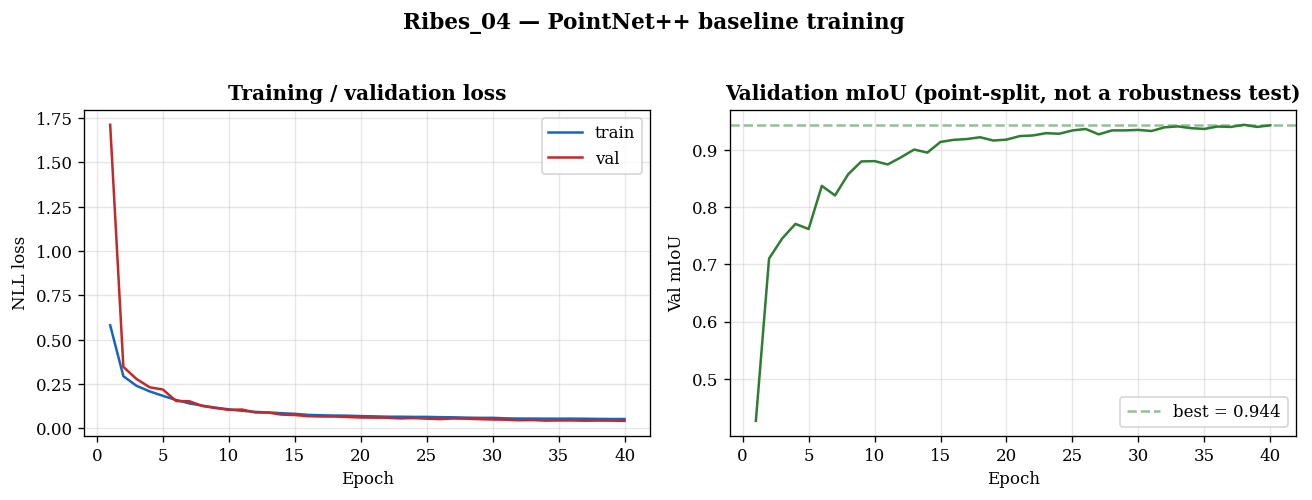

Saved training curves + training_history.csv


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "font.family": "serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.bbox": "tight",
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train", color="#1565c0")
axes[0].plot(history["epoch"], history["val_loss"], label="val", color="#c62828")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NLL loss"); axes[0].set_title("Training / validation loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["val_miou"], color="#2e7d32")
axes[1].axhline(best_val_miou, color="#2e7d32", linestyle="--", alpha=0.5,
                 label=f"best = {best_val_miou:.3f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val mIoU"); axes[1].set_title("Validation mIoU (point-split, not a robustness test)")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f"{PLANT_NAME} — PointNet++ baseline training", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "00_training_curves.png"))
plt.show()

pd_history = None
import pandas as pd
pd_history = pd.DataFrame(history)
pd_history.to_csv(os.path.join(METRICS_DIR, "training_history.csv"), index=False)
print("Saved training curves + training_history.csv")

## 11. Whole-cloud inference — full-coverage chunked prediction

The model only ever sees `N_POINTS_PER_SAMPLE`-point crops, so to label an **entire** cloud
(GT or any noisy variant, of arbitrary size) we run several random permutation passes, chunk
each pass into contiguous blocks of `N_POINTS_PER_SAMPLE` (padding the last block by resampling
already-seen points so every chunk is full-size), predict softmax probabilities per chunk, and
average the probabilities per point across passes — every point is covered by every pass.

In [ ]:
def predict_full_cloud(model, points_norm, features, n_points=N_POINTS_PER_SAMPLE,
                        n_repeats=N_REPEATS_EVAL, batch_size=BATCH_SIZE, device=DEVICE):
    N = points_norm.shape[0]
    prob_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    count = np.zeros(N, dtype=np.int64)
    feat_full = features if (features is not None and ADDITIONAL_CHANNELS > 0) else None

    model.eval()
    with torch.no_grad():
        for rep in range(n_repeats):
            perm = np.random.default_rng(rep * 97 + 1).permutation(N)
            n_chunks = int(np.ceil(N / n_points))
            chunks = []
            for c in range(n_chunks):
                chunk_idx = perm[c * n_points:(c + 1) * n_points]
                if len(chunk_idx) < n_points:
                    pad_rng = np.random.default_rng(rep * 1000 + c)
                    pad = pad_rng.choice(perm, size=n_points - len(chunk_idx), replace=True)
                    chunk_idx = np.concatenate([chunk_idx, pad])
                chunks.append(chunk_idx)

            for b_start in range(0, len(chunks), batch_size):
                batch_chunks = chunks[b_start:b_start + batch_size]
                batch_idx = np.stack(batch_chunks)                      # [B, n_points]
                pts_b = points_norm[batch_idx]                          # [B, n_points, 3]
                pts_t = torch.from_numpy(pts_b.astype(np.float32)).permute(0, 2, 1).to(device)
                if feat_full is not None:
                    feat_b = feat_full[batch_idx]
                    feat_t = torch.from_numpy(feat_b.astype(np.float32)).permute(0, 2, 1).to(device)
                else:
                    feat_t = None
                logits = model(pts_t, feat_t)                            # [B, n_points, C] log-probs
                probs = torch.exp(logits).cpu().numpy()
                for bi, chunk_idx in enumerate(batch_chunks):
                    np.add.at(prob_sum, chunk_idx, probs[bi])
                    np.add.at(count, chunk_idx, 1)

    count[count == 0] = 1
    avg_probs = prob_sum / count[:, None]
    preds = np.argmax(avg_probs, axis=1)
    mean_confidence = float(avg_probs.max(axis=1).mean())
    return preds, avg_probs, mean_confidence

print("Whole-cloud inference utility ready.")

Whole-cloud inference utility ready.


## 12. Evaluate the baseline on clean GT

In [ ]:
t_start = time.time()
gt_preds, gt_probs, gt_mean_conf = predict_full_cloud(model, gt_xyz_norm_full, gt_features_full)
gt_inference_time = time.time() - t_start

gt_metrics = compute_metrics(gt_semantic, gt_preds)
gt_metrics["mean_confidence"] = gt_mean_conf
gt_metrics["inference_time_s"] = gt_inference_time
gt_metrics["n_points"] = N_GT

print(f"GT baseline — mIoU: {gt_metrics['miou']:.4f} | overall accuracy: {gt_metrics['overall_accuracy']:.4f} "
      f"| mean confidence: {gt_mean_conf:.4f} | inference time: {gt_inference_time:.1f}s")
for c in range(NUM_CLASSES):
    name = SEMANTIC_CLASS_NAMES.get(c, str(c))
    print(f"  class {c} ({name:<26}): IoU={gt_metrics['iou_per_class'][c]:.4f}  "
          f"P={gt_metrics['precision_per_class'][c]:.4f}  R={gt_metrics['recall_per_class'][c]:.4f}  "
          f"F1={gt_metrics['f1_per_class'][c]:.4f}  n={gt_metrics['support_per_class'][c]}")

np.save(os.path.join(CM_DIR, "GT_confusion_matrix.npy"), gt_metrics["confusion_matrix"])
GT_MIOU = gt_metrics["miou"]

GT baseline — mIoU: 0.9564 | overall accuracy: 0.9886 | mean confidence: 0.9816 | inference time: 84.3s
  class 0 (Background / Pot / Soil   ): IoU=nan  P=0.0000  R=0.0000  F1=0.0000  n=0
  class 1 (Stem                      ): IoU=0.9262  P=0.9477  R=0.9761  F1=0.9617  n=174696
  class 2 (Leaf                      ): IoU=0.9867  P=0.9959  R=0.9907  F1=0.9933  n=1015670


In [ ]:
import json

def metrics_to_json_safe(m):
    out = {}
    for k, v in m.items():
        if isinstance(v, np.ndarray):
            out[k] = v.tolist()
        else:
            out[k] = v
    return out

with open(os.path.join(METRICS_DIR, "gt_baseline_metrics.json"), "w") as f:
    json.dump(metrics_to_json_safe(gt_metrics), f, indent=2)
print("Saved gt_baseline_metrics.json")

Saved gt_baseline_metrics.json


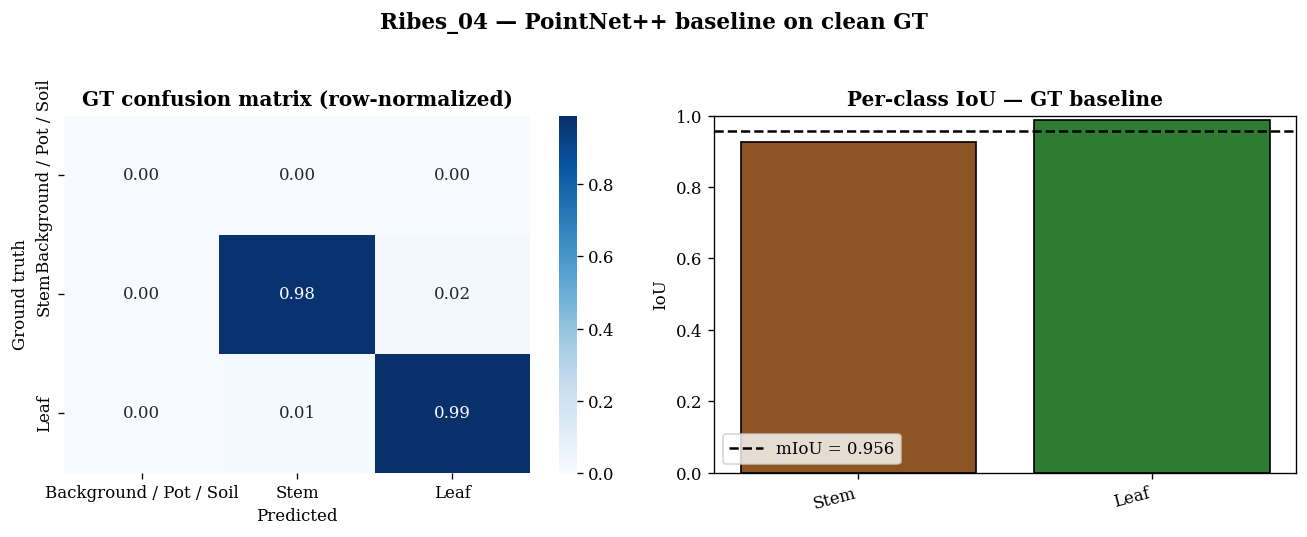

In [ ]:
import seaborn as sns

class_names_short = [SEMANTIC_CLASS_NAMES.get(c, str(c)) for c in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

cm_norm = gt_metrics["confusion_matrix"].astype(float)
cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=True,
            xticklabels=class_names_short, yticklabels=class_names_short, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Ground truth")
axes[0].set_title("GT confusion matrix (row-normalized)")

bar_colors = ["#9e9e9e", "#8d5524", "#2e7d32"][:NUM_CLASSES]
axes[1].bar(class_names_short, gt_metrics["iou_per_class"], color=bar_colors, edgecolor="black")
axes[1].axhline(GT_MIOU, color="black", linestyle="--", label=f"mIoU = {GT_MIOU:.3f}")
axes[1].set_ylabel("IoU"); axes[1].set_ylim(0, 1); axes[1].set_title("Per-class IoU — GT baseline")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(15); tick.set_ha("right")
axes[1].legend()

fig.suptitle(f"{PLANT_NAME} — PointNet++ baseline on clean GT", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_gt_baseline_confusion_and_iou.png"))
plt.show()

## 13. Evaluate on every noisy variant listed in `manifest.csv`

Same frozen model, same `predict_full_cloud` procedure, applied to every `(category, level)`
folder produced by the Degradation Pipeline notebook. RGB features are read from each variant's
own `.ply` (falls back to zero features for a variant if a `.ply` happens to carry no color).

In [ ]:
manifest_df = pd.read_csv(MANIFEST_PATH)
print(f"{len(manifest_df)} noisy variants found in manifest:\n")
print(manifest_df[["category", "level", "n_points", "pct_of_clean"]].to_string(index=False))

21 noisy variants found in manifest:

        category        level  n_points  pct_of_clean
         density          100   1190366        100.00
         density           75    892774         75.00
         density           50    595183         50.00
         density           25    297592         25.00
         density           10    119037         10.00
coordinate_noise          low   1190366        100.00
coordinate_noise       medium   1190366        100.00
coordinate_noise         high   1190366        100.00
  missing_points           10   1071329         90.00
  missing_points           30    833256         70.00
  missing_points           50    595183         50.00
 missing_regions        small   1093706         91.88
 missing_regions       medium    908392         76.31
 missing_regions        large    509112         42.77
  uneven_density         mild    993001         83.42
  uneven_density     moderate    742811         62.40
  uneven_density       severe    576557     

In [ ]:
variant_rows = []
confusion_matrices = {"GT": gt_metrics["confusion_matrix"]}

for _, row in manifest_df.iterrows():
    category, level, out_dir = row["category"], row["level"], row["output_dir"]
    v_ply  = os.path.join(out_dir, f"{PLANT_NAME}.ply")
    v_sem  = os.path.join(out_dir, f"{PLANT_NAME}_SemanticLabels.txt")

    v_points, v_rgb = load_point_cloud(v_ply)
    v_semantic = load_label_file(v_sem, dtype=np.int64)
    assert v_points.shape[0] == v_semantic.shape[0], f"Point/label mismatch for {category}/{level}"

    v_xyz_norm = normalize_xyz(v_points)
    v_features = make_features(v_rgb) if v_rgb is not None else (
        np.zeros((v_points.shape[0], 3)) if ADDITIONAL_CHANNELS > 0 else None)

    t0 = time.time()
    v_preds, v_probs, v_mean_conf = predict_full_cloud(model, v_xyz_norm, v_features)
    inf_time = time.time() - t0

    m = compute_metrics(v_semantic, v_preds)
    delta_miou = GT_MIOU - m["miou"]
    degradation_pct = 100.0 * delta_miou / GT_MIOU if GT_MIOU > 0 else np.nan

    variant_key = f"{category}_{level}"
    confusion_matrices[variant_key] = m["confusion_matrix"]
    np.save(os.path.join(CM_DIR, f"{variant_key}_confusion_matrix.npy"), m["confusion_matrix"])

    result = {
        "category": category, "level": level, "params": row.get("params", ""),
        "n_points": int(v_points.shape[0]), "pct_of_clean": float(row.get("pct_of_clean", np.nan)),
        "gt_miou": GT_MIOU, "miou": m["miou"], "delta_miou": delta_miou, "degradation_pct": degradation_pct,
        "overall_accuracy": m["overall_accuracy"], "mean_confidence": v_mean_conf,
        "inference_time_s": inf_time,
    }
    for c in range(NUM_CLASSES):
        cname = SEMANTIC_CLASS_NAMES.get(c, str(c)).replace(" / ", "_").replace(" ", "_")
        result[f"iou_class{c}_{cname}"] = m["iou_per_class"][c]
        result[f"precision_class{c}_{cname}"] = m["precision_per_class"][c]
        result[f"recall_class{c}_{cname}"] = m["recall_per_class"][c]
        result[f"f1_class{c}_{cname}"] = m["f1_per_class"][c]
        result[f"support_class{c}_{cname}"] = int(m["support_per_class"][c])
    variant_rows.append(result)

    print(f"[{category:<16}/{str(level):<12}] mIoU={m['miou']:.4f}  ΔmIoU={delta_miou:+.4f}  "
          f"degradation={degradation_pct:+5.1f}%  acc={m['overall_accuracy']:.4f}  ({inf_time:.1f}s)")

variant_df = pd.DataFrame(variant_rows)
print(f"\nEvaluated {len(variant_df)} variants.")

[density         /100         ] mIoU=0.9567  ΔmIoU=-0.0003  degradation= -0.0%  acc=0.9887  (79.3s)
[density         /75          ] mIoU=0.9569  ΔmIoU=-0.0004  degradation= -0.0%  acc=0.9887  (58.3s)
[density         /50          ] mIoU=0.9564  ΔmIoU=-0.0000  degradation= -0.0%  acc=0.9886  (39.1s)
[density         /25          ] mIoU=0.9564  ΔmIoU=-0.0000  degradation= -0.0%  acc=0.9886  (20.2s)
[density         /10          ] mIoU=0.9551  ΔmIoU=+0.0013  degradation= +0.1%  acc=0.9882  (8.5s)
[coordinate_noise/low         ] mIoU=0.9563  ΔmIoU=+0.0002  degradation= +0.0%  acc=0.9885  (77.6s)
[coordinate_noise/medium      ] mIoU=0.9498  ΔmIoU=+0.0066  degradation= +0.7%  acc=0.9868  (76.7s)
[coordinate_noise/high        ] mIoU=0.9289  ΔmIoU=+0.0275  degradation= +2.9%  acc=0.9809  (75.7s)
[missing_points  /10          ] mIoU=0.9532  ΔmIoU=+0.0032  degradation= +0.3%  acc=0.9881  (68.6s)
[missing_points  /30          ] mIoU=0.9524  ΔmIoU=+0.0040  degradation= +0.4%  acc=0.9863  (53.8s)
[

In [ ]:
variant_df.to_csv(os.path.join(METRICS_DIR, "variant_metrics.csv"), index=False)
with open(os.path.join(METRICS_DIR, "variant_metrics.json"), "w") as f:
    json.dump(variant_rows, f, indent=2)
print("Saved variant_metrics.csv / variant_metrics.json")

Saved variant_metrics.csv / variant_metrics.json


## 14. Summary table — `Model | GT mIoU | Noisy mIoU | ΔmIoU | Degradation %`

The exact table for the presentation, one row per `(category, level)`, ordered to match the
degradation pipeline's own level ordering.

In [ ]:
LEVEL_ORDER = {
    "density": [100, 75, 50, 25, 10],
    "coordinate_noise": ["low", "medium", "high"],
    "missing_points": [10, 30, 50],
    "missing_regions": ["small", "medium", "large"],
    "uneven_density": ["mild", "moderate", "severe"],
    "illumination": ["dark", "bright", "low_contrast", "color_shift"],
}

def level_sort_key(row):
    order = LEVEL_ORDER.get(row["category"])
    if order is None:
        return (row["category"], 0)
    try:
        return (row["category"], order.index(row["level"]))
    except ValueError:
        try:
            return (row["category"], order.index(int(row["level"])))
        except (ValueError, TypeError):
            return (row["category"], 999)

variant_df["_sort_key"] = variant_df.apply(level_sort_key, axis=1)
variant_df = variant_df.sort_values(by="_sort_key").drop(columns="_sort_key").reset_index(drop=True)

summary_df = pd.DataFrame({
    "Model": "PointNet++ (SSG baseline)",
    "Category": variant_df["category"],
    "Level": variant_df["level"],
    "GT mIoU": np.round(variant_df["gt_miou"], 4),
    "Noisy mIoU": np.round(variant_df["miou"], 4),
    "\u0394mIoU": np.round(variant_df["delta_miou"], 4),
    "Degradation %": np.round(variant_df["degradation_pct"], 2),
})
summary_df.to_csv(os.path.join(METRICS_DIR, "summary_degradation_table.csv"), index=False)
summary_df

,Model,Category,Level,GT mIoU,Noisy mIoU,ΔmIoU,Degradation %
0,PointNet++ (SSG baseline),coordinate_noise,low,0.9564,0.9563,0.0002,0.02
1,PointNet++ (SSG baseline),coordinate_noise,medium,0.9564,0.9498,0.0066,0.69
2,PointNet++ (SSG baseline),coordinate_noise,high,0.9564,0.9289,0.0275,2.88
3,PointNet++ (SSG baseline),density,100,0.9564,0.9567,-0.0003,-0.03
4,PointNet++ (SSG baseline),density,75,0.9564,0.9569,-0.0004,-0.05
5,PointNet++ (SSG baseline),density,50,0.9564,0.9564,-0.0000,-0.00
6,PointNet++ (SSG baseline),density,25,0.9564,0.9564,-0.0000,-0.00
7,PointNet++ (SSG baseline),density,10,0.9564,0.9551,0.0013,0.14
8,PointNet++ (SSG baseline),illumination,dark,0.9564,0.4452,0.5112,53.45
9,PointNet++ (SSG baseline),illumination,bright,0.9564,0.7009,0.2555,26.72


## 15. Figures — mIoU vs. severity, per category

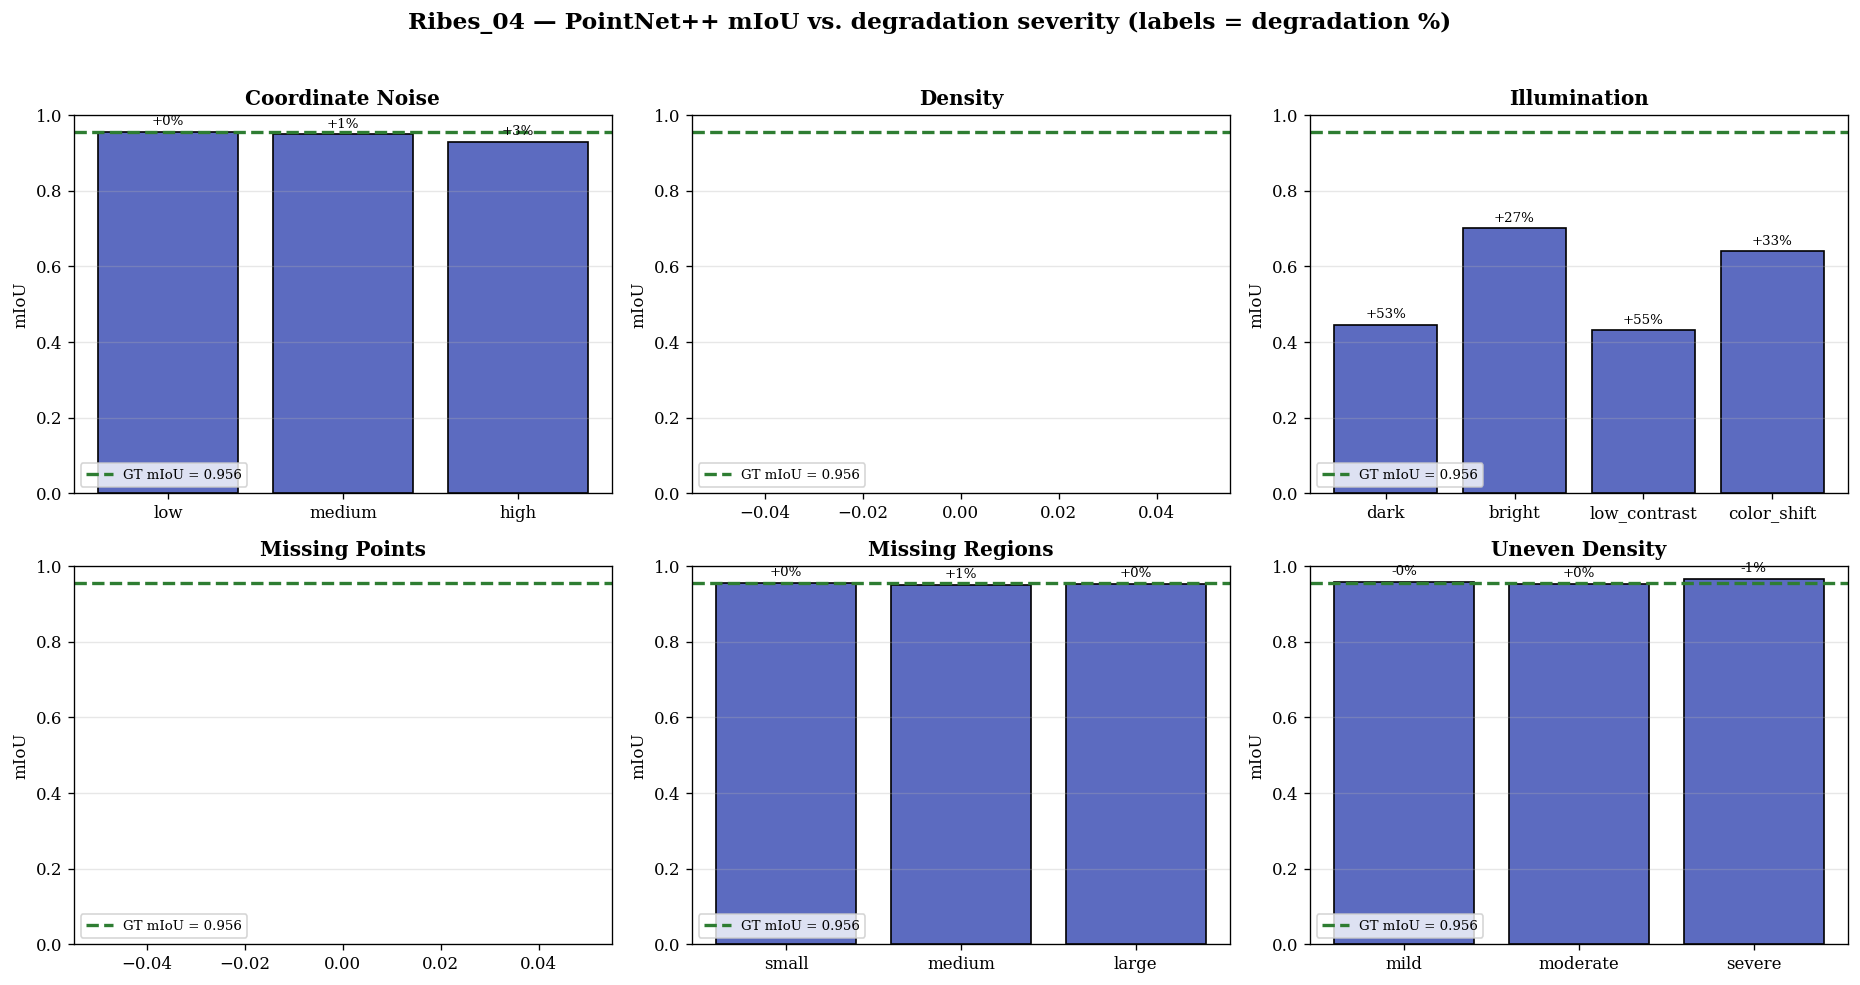

In [ ]:
categories = list(variant_df["category"].unique())
n_cat = len(categories)
n_cols = 3
n_rows = int(np.ceil(n_cat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4 * n_rows), squeeze=False)

for i, cat in enumerate(categories):
    ax = axes[i // n_cols][i % n_cols]
    sub = variant_df[variant_df["category"] == cat]
    order = LEVEL_ORDER.get(cat)
    if order is not None:
        sub = sub.set_index("level").reindex([l for l in order if l in sub["level"].values]).reset_index()
    x_labels = [str(l) for l in sub["level"]]
    bars = ax.bar(x_labels, sub["miou"], color="#5c6bc0", edgecolor="black")
    ax.axhline(GT_MIOU, color="#2e7d32", linestyle="--", linewidth=2, label=f"GT mIoU = {GT_MIOU:.3f}")
    for b, v in zip(bars, sub["degradation_pct"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{v:+.0f}%",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("mIoU")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(axis="y", alpha=0.3)

for j in range(n_cat, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle(f"{PLANT_NAME} — PointNet++ mIoU vs. degradation severity (labels = degradation %)",
             y=1.02, fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_miou_by_category.png"))
plt.show()

## 16. Figure — degradation % heatmap (category × level)

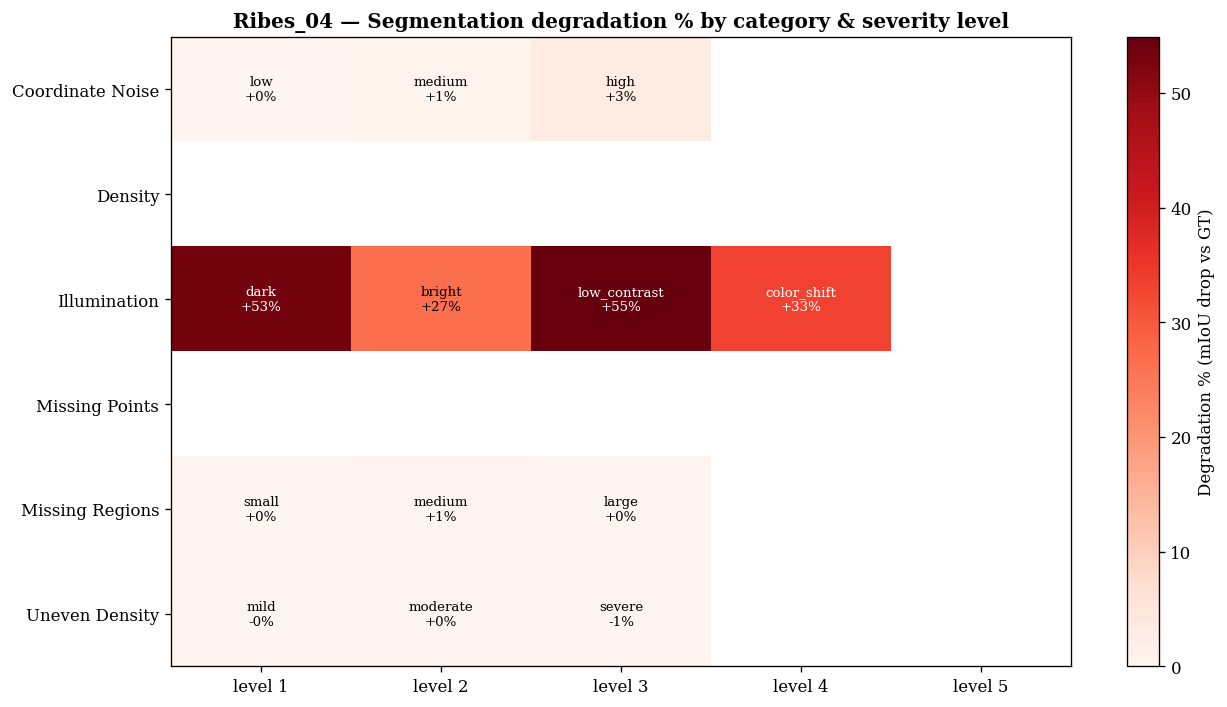

In [ ]:
pivot_rows = []
max_levels = max(len(LEVEL_ORDER.get(cat, variant_df[variant_df.category == cat]["level"].unique()))
                  for cat in categories)

heat = np.full((len(categories), max_levels), np.nan)
col_labels_per_row = []
for i, cat in enumerate(categories):
    sub = variant_df[variant_df["category"] == cat]
    order = LEVEL_ORDER.get(cat, list(sub["level"].unique()))
    order = [l for l in order if l in sub["level"].values]
    col_labels_per_row.append(order)
    for j, lvl in enumerate(order):
        heat[i, j] = sub[sub["level"] == lvl]["degradation_pct"].values[0]

fig, ax = plt.subplots(figsize=(2.2 * max_levels, 0.75 * len(categories) + 1.5))
im = ax.imshow(heat, cmap="Reds", aspect="auto", vmin=0)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels([c.replace("_", " ").title() for c in categories])
ax.set_xticks(range(max_levels))
ax.set_xticklabels([f"level {j+1}" for j in range(max_levels)])
for i in range(len(categories)):
    for j, lvl in enumerate(col_labels_per_row[i]):
        val = heat[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{lvl}\n{val:+.0f}%", ha="center", va="center",
                     fontsize=8, color="black" if val < heat[~np.isnan(heat)].max() * 0.6 else "white")
fig.colorbar(im, ax=ax, label="Degradation % (mIoU drop vs GT)")
ax.set_title(f"{PLANT_NAME} — Segmentation degradation % by category & severity level", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_degradation_pct_heatmap.png"))
plt.show()

## 17. Figure — per-class IoU degradation curves

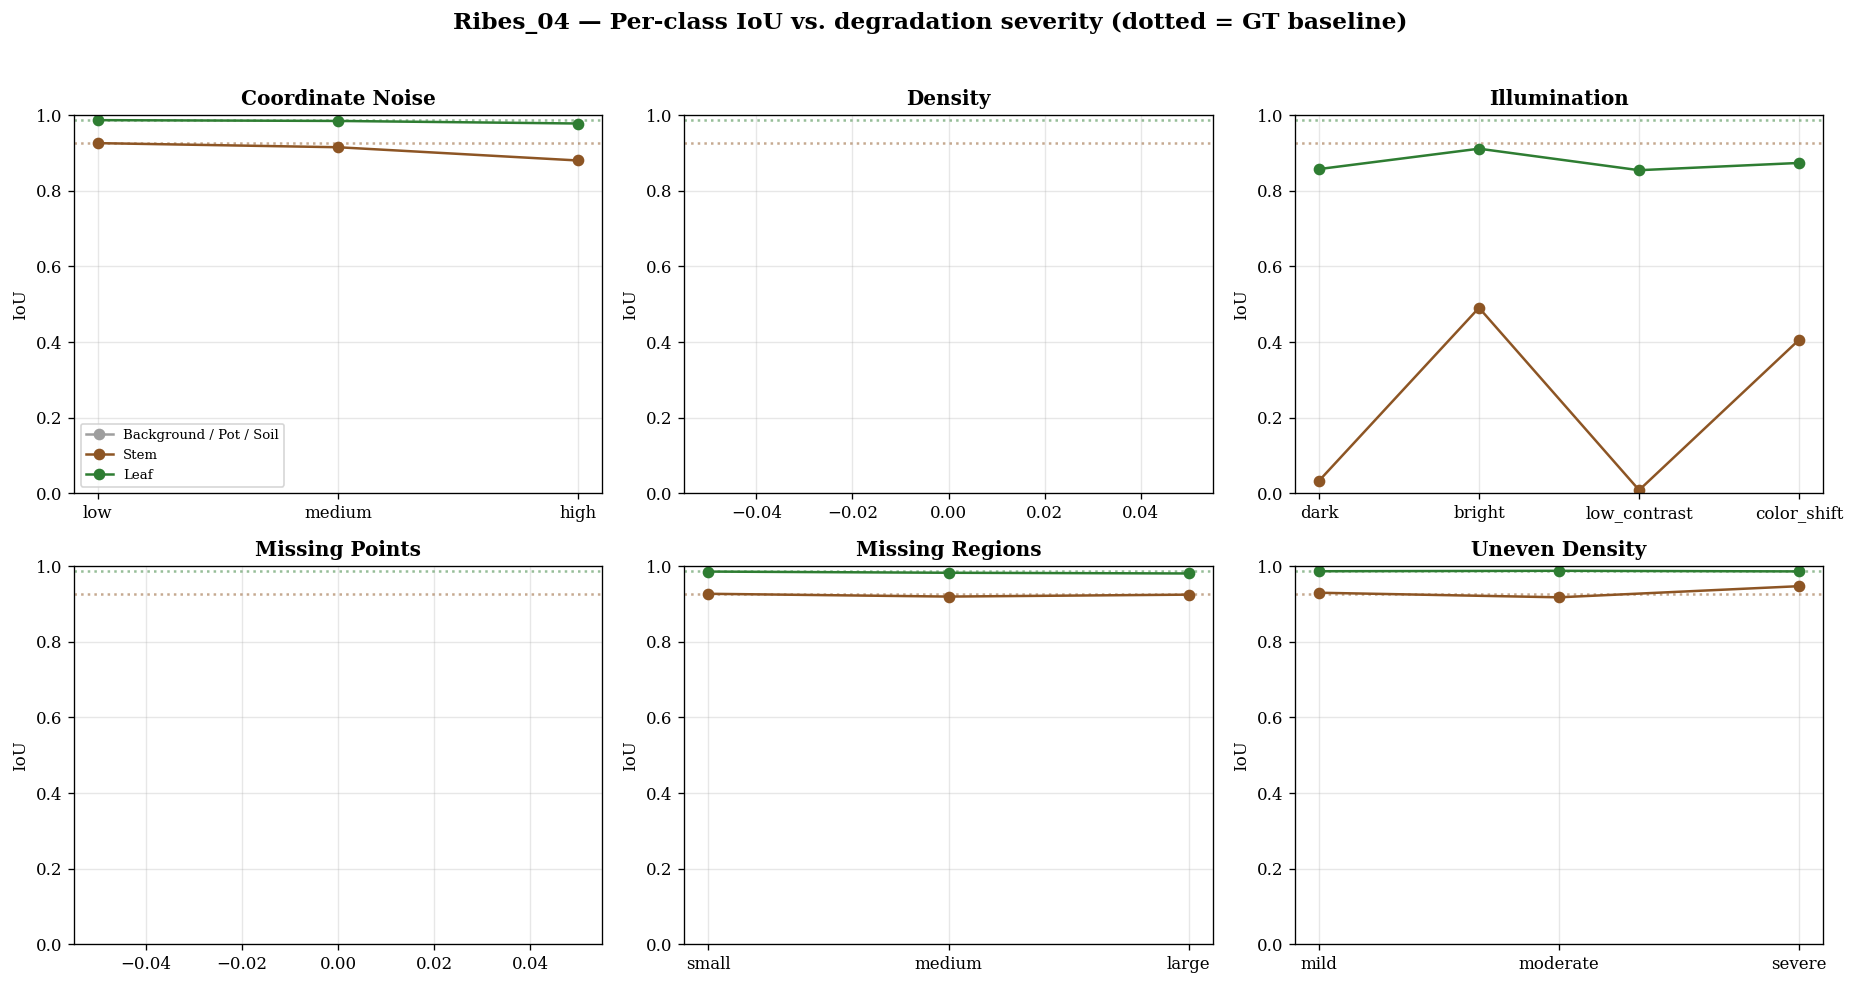

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4 * n_rows), squeeze=False)
class_cols = {c: [col for col in variant_df.columns if col.startswith(f"iou_class{c}_")][0] for c in range(NUM_CLASSES)}
class_colors = ["#9e9e9e", "#8d5524", "#2e7d32"][:NUM_CLASSES]

for i, cat in enumerate(categories):
    ax = axes[i // n_cols][i % n_cols]
    sub = variant_df[variant_df["category"] == cat]
    order = LEVEL_ORDER.get(cat)
    if order is not None:
        sub = sub.set_index("level").reindex([l for l in order if l in sub["level"].values]).reset_index()
    x_labels = [str(l) for l in sub["level"]]
    for c in range(NUM_CLASSES):
        vals = sub[class_cols[c]].values
        ax.plot(x_labels, vals, marker="o", color=class_colors[c],
                label=SEMANTIC_CLASS_NAMES.get(c, str(c)))
        ax.axhline(gt_metrics["iou_per_class"][c], color=class_colors[c], linestyle=":", alpha=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("IoU")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_cat, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle(f"{PLANT_NAME} — Per-class IoU vs. degradation severity (dotted = GT baseline)",
             y=1.02, fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_per_class_iou_degradation.png"))
plt.show()

## 18. Figure — confusion-matrix grid (GT + worst variant per category)

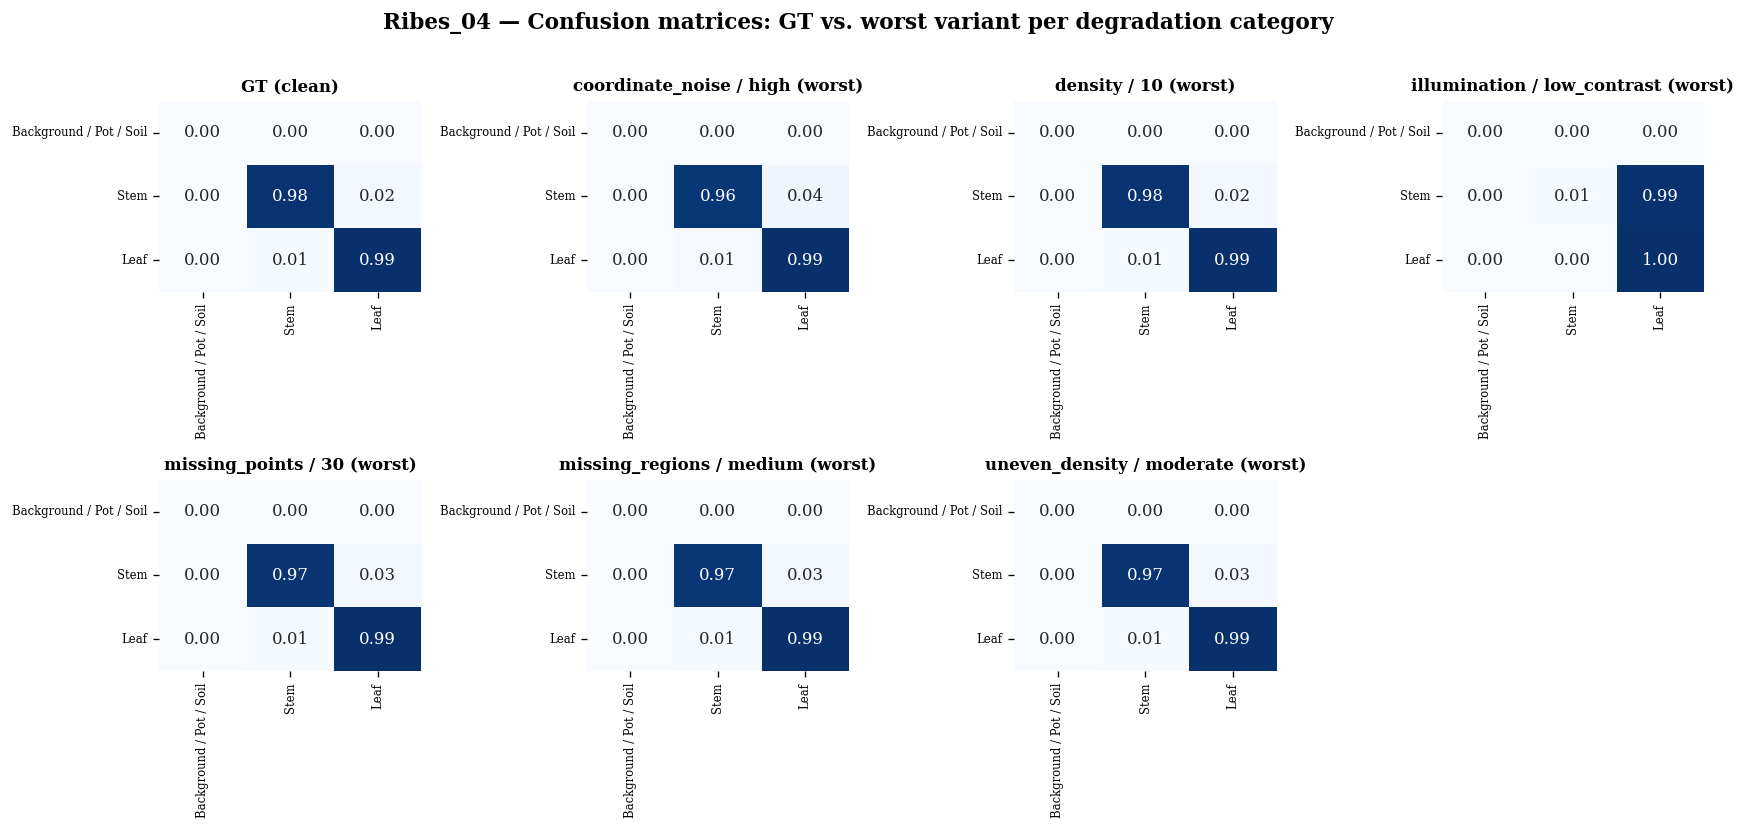

In [ ]:
worst_per_cat = variant_df.loc[variant_df.groupby("category")["miou"].idxmin()]
grid_items = [("GT (clean)", gt_metrics["confusion_matrix"])]
for _, row in worst_per_cat.iterrows():
    key = f"{row['category']}_{row['level']}"
    grid_items.append((f"{row['category']} / {row['level']} (worst)", confusion_matrices[key]))

n_items = len(grid_items)
n_cols_cm = 4
n_rows_cm = int(np.ceil(n_items / n_cols_cm))
fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(3.6 * n_cols_cm, 3.4 * n_rows_cm), squeeze=False)

for idx, (name, cm) in enumerate(grid_items):
    ax = axes[idx // n_cols_cm][idx % n_cols_cm]
    cm_n = cm.astype(float)
    cm_n = cm_n / cm_n.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=class_names_short, yticklabels=class_names_short, ax=ax)
    ax.set_title(name, fontsize=10)
    ax.tick_params(labelsize=7)

for j in range(n_items, n_rows_cm * n_cols_cm):
    axes[j // n_cols_cm][j % n_cols_cm].axis("off")

fig.suptitle(f"{PLANT_NAME} — Confusion matrices: GT vs. worst variant per degradation category",
             y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_confusion_matrix_grid.png"))
plt.show()

## 19. Auto-generated Markdown report

In [ ]:
report_path = os.path.join(REPORT_DIR, "degradation_robustness_report.md")

lines = []
lines.append(f"# PointNet++ Segmentation Robustness — {PLANT_NAME}\n")
lines.append(f"- GT points: **{N_GT:,}**")
lines.append(f"- Model: classic PointNet++ (SSG), {n_params:,} parameters")
lines.append(f"- Training: {EPOCHS} epochs, best val mIoU (point-split) = {best_val_miou:.4f}")
lines.append(f"- **GT baseline mIoU: {GT_MIOU:.4f}** (overall accuracy {gt_metrics['overall_accuracy']:.4f})\n")

lines.append("## Per-class IoU — GT baseline\n")
lines.append("| Class | IoU | Precision | Recall | F1 | Support |")
lines.append("|---|---:|---:|---:|---:|---:|")
for c in range(NUM_CLASSES):
    name = SEMANTIC_CLASS_NAMES.get(c, str(c))
    lines.append(f"| {name} | {gt_metrics['iou_per_class'][c]:.4f} | "
                 f"{gt_metrics['precision_per_class'][c]:.4f} | {gt_metrics['recall_per_class'][c]:.4f} | "
                 f"{gt_metrics['f1_per_class'][c]:.4f} | {int(gt_metrics['support_per_class'][c])} |")

lines.append("\n## Degradation summary — Model / GT mIoU / Noisy mIoU / \u0394mIoU / Degradation %\n")
lines.append("| Model | Category | Level | GT mIoU | Noisy mIoU | \u0394mIoU | Degradation % |")
lines.append("|---|---|---|---:|---:|---:|---:|")
for _, r in summary_df.iterrows():
    lines.append(f"| {r['Model']} | {r['Category']} | {r['Level']} | {r['GT mIoU']:.4f} | "
                 f"{r['Noisy mIoU']:.4f} | {r['\u0394mIoU']:.4f} | {r['Degradation %']:.2f}% |")

lines.append("\n## Most / least robust variant\n")
worst_row = variant_df.loc[variant_df["degradation_pct"].idxmax()]
best_row = variant_df.loc[variant_df["degradation_pct"].idxmin()]
lines.append(f"- **Most degrading**: `{worst_row['category']}/{worst_row['level']}` "
             f"(mIoU {worst_row['miou']:.4f}, {worst_row['degradation_pct']:+.1f}%)")
lines.append(f"- **Least degrading**: `{best_row['category']}/{best_row['level']}` "
             f"(mIoU {best_row['miou']:.4f}, {best_row['degradation_pct']:+.1f}%)")

lines.append("\n## Figures\n")
lines.append("- `figures/00_training_curves.png`")
lines.append("- `figures/01_gt_baseline_confusion_and_iou.png`")
lines.append("- `figures/02_miou_by_category.png`")
lines.append("- `figures/03_degradation_pct_heatmap.png`")
lines.append("- `figures/04_per_class_iou_degradation.png`")
lines.append("- `figures/05_confusion_matrix_grid.png`")

with open(report_path, "w") as f:
    f.write("\n".join(lines))

print(f"Report saved to: {report_path}")
print("\n".join(lines[:20]))

Report saved to: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval/report/degradation_robustness_report.md
# PointNet++ Segmentation Robustness — Ribes_04

- GT points: **1,190,366**
- Model: classic PointNet++ (SSG), 967,555 parameters
- Training: 40 epochs, best val mIoU (point-split) = 0.9443
- **GT baseline mIoU: 0.9564** (overall accuracy 0.9886)

## Per-class IoU — GT baseline

| Class | IoU | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|---:|
| Background / Pot / Soil | nan | 0.0000 | 0.0000 | 0.0000 | 0 |
| Stem | 0.9262 | 0.9477 | 0.9761 | 0.9617 | 174696 |
| Leaf | 0.9867 | 0.9959 | 0.9907 | 0.9933 | 1015670 |

## Degradation summary — Model / GT mIoU / Noisy mIoU / ΔmIoU / Degradation %

| Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation % |
|---|---|---|---:|---:|---:|---:|
| PointNet++ (SSG baseline) | coordinate_noise | low | 0.9564 | 0.9563 | 0.0002 | 0.02% |
| PointNet++ (SSG baseline) | coordin

## ✅ Done

```
outputs/Ribes_04/robustness_eval/
├── checkpoints/
│   └── pointnet2_best.pth
├── tables/
│   ├── training_history.csv
│   ├── gt_baseline_metrics.json
│   ├── variant_metrics.csv
│   ├── variant_metrics.json
│   ├── summary_degradation_table.csv        <- Model | GT mIoU | Noisy mIoU | ΔmIoU | Degradation %
│   └── confusion_matrices/
│       ├── GT_confusion_matrix.npy
│       └── <category>_<level>_confusion_matrix.npy   (one per manifest row)
├── figures/
│   ├── 00_training_curves.png
│   ├── 01_gt_baseline_confusion_and_iou.png
│   ├── 02_miou_by_category.png
│   ├── 03_degradation_pct_heatmap.png
│   ├── 04_per_class_iou_degradation.png
│   └── 05_confusion_matrix_grid.png
└── report/
    └── degradation_robustness_report.md
```

No `.ply` files are written anywhere by this notebook — only metrics (`.csv` / `.json` / `.npy`),
figures (`.png`), the trained checkpoint, and the Markdown report.

**To re-run for another plant:** change `PLANT_NAME` in Section 2 (make sure that plant's
`gt_reconstruction/` files and `noisy_reconstruction/degraded/.../manifest.csv` already exist —
i.e. re-run the other two notebooks for that plant first).
